### LSTM 

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import ast

In [9]:


HORIZON = 24
SEQ_LEN = 48
EPOCHS = 30


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df["hour"] = df["datetime"].dt.hour

df["lag_1"] = df["value_spot"].shift(1)
df["lag_2"] = df["value_spot"].shift(2)
df["lag_24"] = df["value_spot"].shift(24)

df = df.ffill()



df = pd.get_dummies(df, columns=[c for c in ["zone_prev", "zone"] if c in df.columns], drop_first=True)

# IMPORT
df["import"] = df["import"].apply(ast.literal_eval)
import_expanded = df["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df["export"] = df["export"].apply(ast.literal_eval)
export_expanded = df["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df = pd.concat(
    [df.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df["mix"] = df["mix"].apply(ast.literal_eval)
expanded = df["mix"].apply(pd.Series)
df = pd.concat([df.drop(columns=["mix"]), expanded], axis=1)



df = df.join(df["flows"].apply(pd.Series))

df = df.fillna(0)

df = df.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])




before 34994


In [10]:
df["value_spot"].describe()

count    34994.000000
mean       149.466225
std        128.188643
min       -440.100000
25%         70.080000
50%        112.870000
75%        193.722500
max        871.000000
Name: value_spot, dtype: float64

In [11]:
for i in range(1, HORIZON + 1):
    df[f"price_t+{i}"] = df["value_spot"].shift(-i)
    df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON + 1)] +
    [f"carbon_t+{i}" for i in range(1, HORIZON + 1)]
)

X = df.drop(columns=target_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

In [12]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, num_layers=5, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 48)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [13]:
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :24]
carbon_pred = preds[:, 24:]

price_true = actuals[:, :24]
carbon_true = actuals[:, 24:]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 666824.48, Val: 37541.04
Epoch 2, Train: 643972.90, Val: 31655.75
Epoch 3, Train: 571354.09, Val: 20595.80
Epoch 4, Train: 456484.93, Val: 9887.85
Epoch 5, Train: 329589.26, Val: 7985.56
Epoch 6, Train: 233726.24, Val: 18641.20
Epoch 7, Train: 195254.60, Val: 32685.72
Epoch 8, Train: 188370.97, Val: 38235.21
Epoch 9, Train: 187734.92, Val: 36687.14
Epoch 10, Train: 186931.08, Val: 35624.20
Epoch 11, Train: 186999.58, Val: 34978.14
Epoch 12, Train: 186971.47, Val: 34914.69
Epoch 13, Train: 187243.52, Val: 35888.85
Epoch 14, Train: 186930.52, Val: 35863.70
Epoch 15, Train: 187432.96, Val: 35711.48
Epoch 16, Train: 187449.18, Val: 35218.78
Epoch 17, Train: 186970.72, Val: 35854.76
Epoch 18, Train: 187116.19, Val: 35265.64
Epoch 19, Train: 186976.29, Val: 36186.58
Epoch 20, Train: 187149.03, Val: 35886.79
Epoch 21, Train: 187004.44, Val: 35433.66
Epoch 22, Train: 187238.79, Val: 35397.85
Epoch 23, Train: 187057.14, Val: 35666.50
Epoch 24, Train: 187262.40, Val: 35474.40
Epo

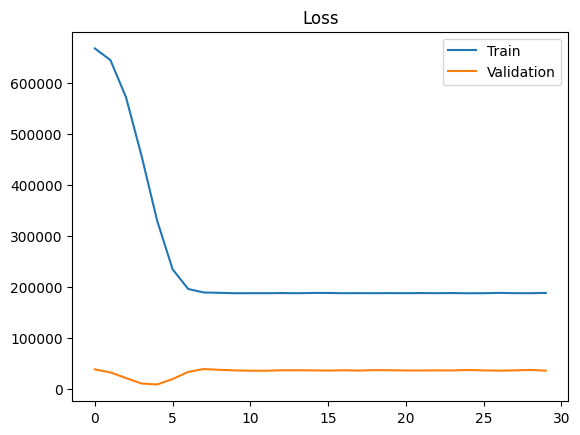

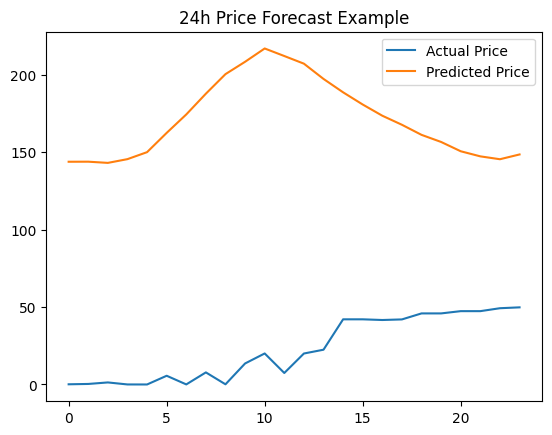

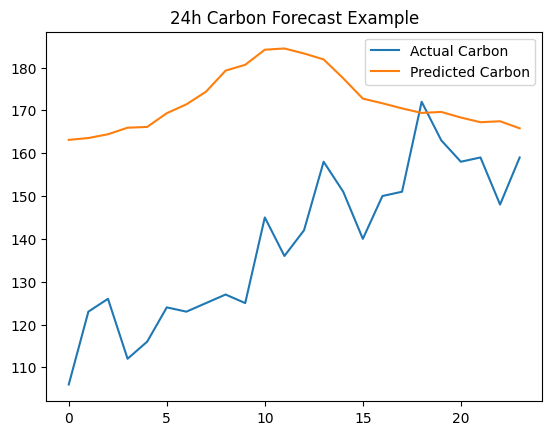

In [14]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("24h Price Forecast Example")
plt.show()

plt.figure()
plt.plot(carbon_true[idx], label="Actual Carbon")
plt.plot(carbon_pred[idx], label="Predicted Carbon")
plt.legend()
plt.title("24h Carbon Forecast Example")
plt.show()

In [16]:


HORIZON = 24
SEQ_LEN = 48
EPOCHS = 30


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df["hour"] = df["datetime"].dt.hour

df["lag_1"] = df["value_spot"].shift(1)
df["lag_2"] = df["value_spot"].shift(2)
df["lag_24"] = df["value_spot"].shift(24)

df = df.ffill()



df = pd.get_dummies(df, columns=[c for c in ["zone_prev", "zone"] if c in df.columns], drop_first=True)

# IMPORT
df["import"] = df["import"].apply(ast.literal_eval)
import_expanded = df["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df["export"] = df["export"].apply(ast.literal_eval)
export_expanded = df["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df = pd.concat(
    [df.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df["mix"] = df["mix"].apply(ast.literal_eval)
expanded = df["mix"].apply(pd.Series)
df = pd.concat([df.drop(columns=["mix"]), expanded], axis=1)



df = df.join(df["flows"].apply(pd.Series))

df = df.fillna(0)

df = df.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])




df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["weekday_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * (df["month"] -1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] -1)/ 12)

before 34994


In [17]:
for i in range(1, HORIZON + 1):
    df[f"price_t+{i}"] = df["value_spot"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON + 1)] 
)

drop_cols = ["hour", "weekday","month"]

X = df.drop(columns=target_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

In [20]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, num_layers=5, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 24)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [21]:
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :24]
carbon_pred = preds[:, 24:]

price_true = actuals[:, :24]
carbon_true = actuals[:, 24:]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 2757.28, Val: 299.51
Epoch 2, Train: 2693.81, Val: 272.04
Epoch 3, Train: 2507.17, Val: 217.06
Epoch 4, Train: 2192.80, Val: 149.23
Epoch 5, Train: 1838.64, Val: 135.27
Epoch 6, Train: 1610.08, Val: 231.50
Epoch 7, Train: 1558.45, Val: 278.21
Epoch 8, Train: 1551.51, Val: 276.59
Epoch 9, Train: 1549.60, Val: 261.78
Epoch 10, Train: 1549.33, Val: 261.04
Epoch 11, Train: 1548.63, Val: 263.41
Epoch 12, Train: 1548.39, Val: 267.61
Epoch 13, Train: 1549.79, Val: 270.32
Epoch 14, Train: 1550.04, Val: 267.33
Epoch 15, Train: 1549.62, Val: 264.30
Epoch 16, Train: 1551.32, Val: 265.87
Epoch 17, Train: 1550.25, Val: 276.68
Epoch 18, Train: 1547.86, Val: 265.18
Epoch 19, Train: 1549.40, Val: 260.89
Epoch 20, Train: 1552.15, Val: 253.62
Epoch 21, Train: 1548.71, Val: 279.18
Epoch 22, Train: 1549.72, Val: 267.53
Epoch 23, Train: 1550.04, Val: 261.17
Epoch 24, Train: 1548.90, Val: 269.21
Epoch 25, Train: 1547.52, Val: 270.67
Epoch 26, Train: 1552.20, Val: 254.21
Epoch 27, Train: 1550

/Users/ludviglindmark/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/Kandidat/Advanced BA/Advanced_business_analytics/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ludviglindmark/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/Kandidat/Advanced BA/Advanced_business_analytics/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


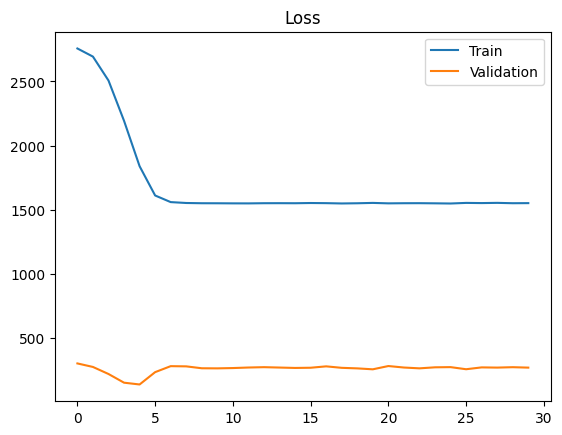

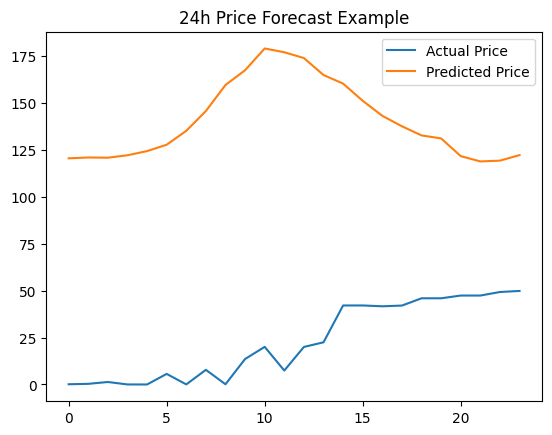

In [22]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("24h Price Forecast Example")
plt.show()


In [42]:
for i in range(1, HORIZON + 1):
    df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"carbon_t+{i}" for i in range(1, HORIZON + 1)] 
)

drop_cols = ["hour", "weekday","month"]

X = df.drop(columns=target_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

In [43]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 24, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(24, 256),
            nn.ReLU(),
            nn.Linear(256, 24)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [44]:
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

carbon_pred = preds[:, :24]

carbon_true = actuals[:, :24]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 573355.50, Val: 47834.87
Epoch 2, Train: 567793.78, Val: 46190.20
Epoch 3, Train: 542396.73, Val: 39447.45
Epoch 4, Train: 479024.24, Val: 27860.21
Epoch 5, Train: 381858.20, Val: 15598.69
Epoch 6, Train: 278546.31, Val: 7537.70
Epoch 7, Train: 189915.56, Val: 6498.74
Epoch 8, Train: 132514.45, Val: 11864.80
Epoch 9, Train: 105835.55, Val: 19327.85
Epoch 10, Train: 98106.85, Val: 24176.36
Epoch 11, Train: 96946.76, Val: 26316.53
Epoch 12, Train: 95221.43, Val: 16377.06
Epoch 13, Train: 86788.64, Val: 9530.32
Epoch 14, Train: 80597.98, Val: 6204.86
Epoch 15, Train: 77198.22, Val: 6212.55
Epoch 16, Train: 74206.23, Val: 6183.74
Epoch 17, Train: 71037.58, Val: 6188.97
Epoch 18, Train: 63707.76, Val: 6682.96
Epoch 19, Train: 58813.97, Val: 5701.00
Epoch 20, Train: 55182.77, Val: 6255.81
Epoch 21, Train: 52344.74, Val: 6750.89
Epoch 22, Train: 50649.55, Val: 5937.12
Epoch 23, Train: 49650.43, Val: 6636.87
Epoch 24, Train: 48144.85, Val: 7131.39
Epoch 25, Train: 47366.49, Val

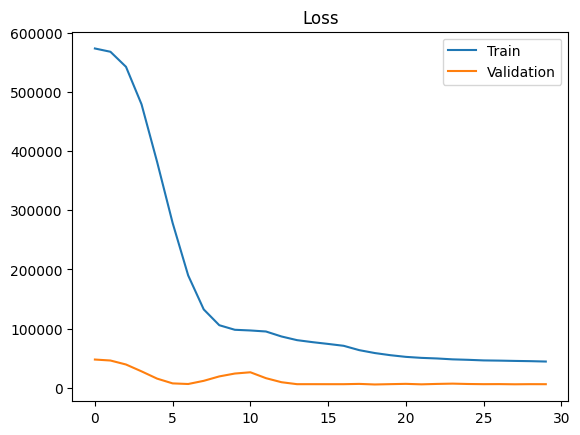

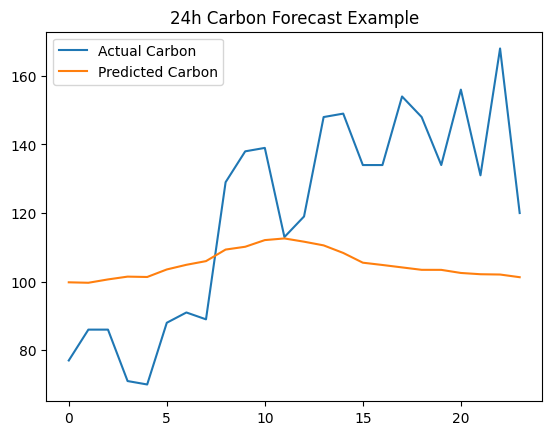

In [45]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(carbon_true[idx], label="Actual Carbon")
plt.plot(carbon_pred[idx], label="Predicted Carbon")
plt.legend()
plt.title("24h Carbon Forecast Example")
plt.show()